Загрузим датасет

In [235]:
import pandas as pd
import glob
import os



df = pd.read_table(r"final.csv", sep=";")
df = df.drop_duplicates()



Посмотрим характеристики

In [236]:
df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 55152 entries, 0 to 61677
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   accommodation_type    55152 non-null  str    
 1   author                54079 non-null  str    
 2   author_type           54079 non-null  str    
 3   deal_type             55152 non-null  str    
 4   description           55152 non-null  str    
 5   district              41736 non-null  str    
 6   finish_type           55152 non-null  str    
 7   floor                 55152 non-null  int64  
 8   floors_count          55152 non-null  int64  
 9   heating_type          55152 non-null  int64  
 10  house_material_type   55152 non-null  str    
 11  house_number          48252 non-null  str    
 12  kitchen_meters        55152 non-null  str    
 13  living_meters         55152 non-null  str    
 14  location              55152 non-null  str    
 15  metro_distance        55152 non-nul

,accommodation_type,author,author_type,deal_type,description,district,finish_type,floor,floors_count,heating_type,...,phone,price,residential_complex,rooms_count,street,total_meters,transport_score,underground,url,year_of_construction
0,flat,Центр Инвест,real_estate_agent,sale,О ПРОЕКТЕ:\n\nWill Towers — жилой комплекс биз...,Раменки,Без отделки,35,56,-1,...,7.923071e+10,28127104,Will Towers,2,проспект Генерала Дорохова,51.3,5.2,Минская,https://www.cian.ru/sale/flat/320392576/?mlSea...,2024
1,flat,Apple Real Estate,real_estate_agent,sale,Лот 1000259. Виктория Шевцова.\n\nРады предлож...,Раменки,-1,9,19,-1,...,7.915314e+10,41500000,Золотые Ключи 2,2,Минская,67.0,-1.0,Минская,https://www.cian.ru/sale/flat/326688167/?mlSea...,2004
2,flat,ID 119690304,homeowner,sale,УСЛУГИ ПРОСЬБА НЕ ПРЕДЛАГАТЬ !!! \nПродает соб...,Филевский парк,-1,7,8,-1,...,7.916816e+10,17850000,NaN,2,Василисы Кожиной,40.0,-1.0,Минская,https://www.cian.ru/sale/flat/322956324/?mlSea...,1960
3,flat,Центр Инвест,real_estate_agent,sale,О ПРОЕКТЕ:\n\nWill Towers — жилой комплекс биз...,Раменки,Без отделки,33,56,-1,...,7.923071e+10,38320818,Will Towers,2,проспект Генерала Дорохова,73.4,5.2,Минская,https://www.cian.ru/sale/flat/320392568/?mlSea...,2024
4,flat,Whitewill,real_estate_agent,sale,Квартира с двумя спальнями в комплексе премиум...,Раменки,Чистовая,23,40,-1,...,7.985722e+10,51000000,Нова ЖК,2,NaN,54.0,-1.0,Минская,https://www.cian.ru/sale/flat/327116733/?mlSea...,2027


Удалим ненужные столбцы: author, author_type, description, house_number, nearest_metro, phone, residential_complex, street, underground, url

In [237]:
df.drop(columns=['author', 'author_type', 'description', 'house_number', 'nearest_metro', 'phone', 'residential_complex', 'street', 'underground', 'url'], inplace=True)
df.head()

,accommodation_type,deal_type,district,finish_type,floor,floors_count,heating_type,house_material_type,kitchen_meters,living_meters,location,metro_distance,object_type,price,rooms_count,total_meters,transport_score,year_of_construction
0,flat,sale,Раменки,Без отделки,35,56,-1,Монолитный,6 м²,"33,3 м²",Москва,19,-1,28127104,2,51.3,5.2,2024
1,flat,sale,Раменки,-1,9,19,-1,-1,18 м²,20 м²,Москва,16,-1,41500000,2,67.0,-1.0,2004
2,flat,sale,Филевский парк,-1,7,8,-1,-1,15 м²,20 м²,Москва,11,-1,17850000,2,40.0,-1.0,1960
3,flat,sale,Раменки,Без отделки,33,56,-1,Монолитный,"6,1 м²","44,8 м²",Москва,19,-1,38320818,2,73.4,5.2,2024
4,flat,sale,Раменки,Чистовая,23,40,-1,-1,-1,49 м²,Москва,15,-1,51000000,2,54.0,-1.0,2027


Посмотрим, какие переменные содержат столбцы: accomodation_type, deal_type, finish_type, heating_type, house_material_type, location, object_type

In [238]:
columns = ['accommodation_type', 'deal_type', 'finish_type', 'heating_type', 'house_material_type', 'location', 'object_type']
for i in columns:
	print(df[i].value_counts())

accommodation_type
flat    55152
Name: count, dtype: int64
deal_type
sale    55152
Name: count, dtype: int64
finish_type
-1                                                         40266
Без отделки                                                 5430
Без отделки, предчистовая                                   2505
Без отделки, предчистовая, чистовая                         1942
Чистовая                                                    1908
Без отделки, чистовая                                        964
Предчистовая                                                 458
Без отделки, предчистовая, черновая, чистовая                356
Предчистовая, чистовая                                       250
Без отделки, предчистовая, черновая                          235
-                                                            235
Без отделки, чистовая с мебелью                              106
Без отделки, чистовая, чистовая с мебелью                    104
Без отделки, предчистовая, чистова

Удалим столбцы flat, deal_type, location, object_type, поскольку в них для всех наблюдений одинаковые значения. Удалим finish_type, heating_type, house_material_type - поскольку их значения отсутствуют для большинства наблюдений

In [239]:
df.drop(columns=['accommodation_type', 'deal_type', 'finish_type', 'heating_type', 'house_material_type', 'location', 'object_type'], inplace=True)
df.head()

,district,floor,floors_count,kitchen_meters,living_meters,metro_distance,price,rooms_count,total_meters,transport_score,year_of_construction
0,Раменки,35,56,6 м²,"33,3 м²",19,28127104,2,51.3,5.2,2024
1,Раменки,9,19,18 м²,20 м²,16,41500000,2,67.0,-1.0,2004
2,Филевский парк,7,8,15 м²,20 м²,11,17850000,2,40.0,-1.0,1960
3,Раменки,33,56,"6,1 м²","44,8 м²",19,38320818,2,73.4,5.2,2024
4,Раменки,23,40,-1,49 м²,15,51000000,2,54.0,-1.0,2027


Проверим оставшиеся столбцы на значения

In [240]:
print(df.shape)
for i in df.columns:
    print(df[i].value_counts())
    print("Nan")
    print(df[i].isna().sum())
    print("_____________________")

(55152, 11)
district
Пресненский                                                                                                                                                   2692
Раменки                                                                                                                                                       1796
Тверской                                                                                                                                                      1781
Даниловский                                                                                                                                                   1231
Хамовники                                                                                                                                                     1217
                                                                                                                                                              ... 
в

1. Удалим столбец transporte_score, почти целиком состоящий из пропусков.
2. Преобразуем стобец district в str, очистим его от мусора, удалим данные с пропусками.
3. Уберем лишние символы из kitchen_meters, приведем данные к типу float, заменим пропуски -1 на np.nan
4. Пункт 3 проделаем и для living_meters.
5. Удалим записи с пропусками room_count
6. Столбец total_meters приведём к float, удалим наблюдения с пропусками.
7. year_of_construction - заменим -1 на np.nan

In [241]:
df.drop(columns=["transport_score"], inplace=True)


df["district"] = df["district"].map(lambda x: x if pd.isna(x) else x.lower())
import json
with open("county_district.json", 'r', encoding='utf-8') as file:
    districts = json.load(file)
new_districts = dict()
for i in districts:
    name = i['name'].lower()
    district_id = i['id']
    new_districts[name] = district_id
df['district'] = df['district'].replace(new_districts)
df['district'] = pd.to_numeric(df['district'], errors='coerce') #TODO INT
df = df.dropna(subset=['district'])
df['district'].value_counts()

import numpy as np
df["kitchen_meters"] = df["kitchen_meters"].map(lambda x: x if x == -1 else float(x.split()[0].replace(',', '.')))
df["kitchen_meters"] = df["kitchen_meters"].astype("float64")
df["kitchen_meters"] = df["kitchen_meters"].map(lambda x: np.nan if x == -1.0 else x)

df["living_meters"] = df["living_meters"].map(lambda x: x if x == -1 else float(x.split()[0].replace(',', '.')))
df["living_meters"] = df["living_meters"].astype("float64")
df["living_meters"] = df["living_meters"].map(lambda x: np.nan if x == -1.0 else x)


df["rooms_count"] = df["rooms_count"].map(lambda x: np.nan if x == -1 else x)
df = df.dropna(subset=['rooms_count'])

df["total_meters"] = df["total_meters"].astype("float64")
df["total_meters"] = df["total_meters"].map(lambda x: np.nan if x == -1.0 else x)
df = df.dropna(subset=['total_meters'])


df["kitchen_meters"] = pd.to_numeric(df["kitchen_meters"], errors="coerce")

df['year_of_construction'] = pd.to_numeric(df['year_of_construction'], errors='coerce')
print(df["year_of_construction"].dtype)
df["year_of_construction"] = df["year_of_construction"].replace(-1, np.nan)



float64


Посмотрим на данные

In [242]:
print(df.shape)
for i in df.columns:
    print(df[i].value_counts())
    print("_____________________")
df = df.replace([-1, -1.0], np.nan)

(38869, 10)
district
61.0     2683
51.0     1785
63.0     1775
97.0     1229
64.0     1199
         ... 
43.0       11
124.0      10
70.0        5
111.0       2
146.0       1
Name: count, Length: 126, dtype: int64
_____________________
floor
2     4080
3     3588
4     3312
5     3216
6     2368
      ... 
77       2
64       2
70       1
69       1
74       1
Name: count, Length: 79, dtype: int64
_____________________
floors_count
9     3698
12    2578
17    2410
5     2366
14    2047
      ... 
97       3
60       2
80       1
83       1
95       1
Name: count, Length: 81, dtype: int64
_____________________
kitchen_meters
10.0    2526
6.0     2036
8.0     1387
9.0     1386
15.0    1219
        ... 
63.3       1
52.5       1
54.2       1
84.9       1
50.4       1
Name: count, Length: 565, dtype: int64
_____________________
living_meters
20.0     907
19.0     717
18.0     716
30.0     480
45.0     449
        ... 
109.4      1
68.8       1
110.9      1
108.2      1
91.2       1
Name: c

# ЗАМЕНИЛИ РАЙОН НА ОКРУГА

In [243]:
# for i in districts:
#     district_id = i['id']
#     county_id = i['county_id']
#     new_districts[district_id] = county_id
#
#
# df['district'] = df['district'].replace(new_districts)
# df.head()

Заполним пропуски с помощью KNNImputer

In [244]:

from sklearn.impute import KNNImputer
imputer = KNNImputer().set_output(transform="pandas")
df = imputer.fit_transform(df)


Применим OneHotEncoding для столбца District

In [245]:
df = pd.get_dummies(df, columns=["district"])

Ищем выбросы

In [246]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Предполагаем, что df уже загружен

# Определяем столбцы для визуализации

def visual(df):
    plots_config = {
        'kitchen_meters': {'type': 'continuous', 'xlim': None, 'title': 'Кухня (м²)'},
        'living_meters': {'type': 'continuous', 'xlim': None, 'title': 'Жилая площадь (м²)'},
        'total_meters': {'type': 'continuous', 'xlim': None, 'title': 'Общая площадь (м²)'},
        'year_of_construction': {'type': 'grouped_years', 'bin_years': 5, 'title': 'Год постройки (группировка по 5 лет)'},
        'floor': {'type': 'discrete', 'title': 'Этаж'},
        'floors_count': {'type': 'discrete', 'title': 'Количество этажей в доме'},
        'metro_distance': {'type': 'continuous', 'xlim': None, 'title': 'Расстояние до метро (мин)'},
        'price': {'type': 'continuous', 'xlim': (0, 300000000), 'title': 'Цена'}
    }

    # Оставляем только существующие столбцы
    plots_config = {col: config for col, config in plots_config.items() if col in df.columns}

    # Создаём отдельные графики (каждый в своём окне или в сетке с одним столбцом)
    fig, axes = plt.subplots(len(plots_config), 1, figsize=(14, 6 * len(plots_config)))
    if len(plots_config) == 1:
        axes = [axes]

    for idx, (col, config) in enumerate(plots_config.items()):
        data = df[col].dropna()

        if config['type'] == 'continuous':
            # Определяем границы (обрезаем выбросы)
            lower = data.quantile(0.01)
            upper = data.quantile(0.99)

            # Применяем пользовательские xlim, если заданы
            xlim_lower = config['xlim'][0] if config['xlim'] is not None else lower
            xlim_upper = config['xlim'][1] if config['xlim'] is not None else upper

            # Фильтруем данные
            data_filtered = data[(data >= xlim_lower) & (data <= xlim_upper)]

            # Строим гистограмму
            axes[idx].hist(data_filtered, bins=50, edgecolor='black', alpha=0.7, color='steelblue')

            # Добавляем линии среднего и медианы
            mean_val = data_filtered.mean()
            median_val = data_filtered.median()
            axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2,
                             label=f'Среднее: {mean_val:.1f}')
            axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2,
                             label=f'Медиана: {median_val:.1f}')

            axes[idx].set_xlim(xlim_lower, xlim_upper)

        elif config['type'] == 'grouped_years':
            # Группировка по N лет
            bin_years = config['bin_years']
            # Создаём группы
            min_year = data.min()
            max_year = data.max()
            bins = np.arange(min_year - (min_year % bin_years), max_year + bin_years, bin_years)

            # Группируем данные
            data_grouped = pd.cut(data, bins=bins, right=False)
            counts = data_grouped.value_counts().sort_index()

            # Убираем группы с нулевыми значениями
            counts = counts[counts > 0]

            # Создаём метки для оси X
            labels = [f"{int(bin.left)}-{int(bin.right)}" for bin in counts.index]

            # Строим столбчатую диаграмму
            axes[idx].bar(range(len(counts)), counts.values, edgecolor='black', alpha=0.7,
                         color='steelblue', width=0.8)
            axes[idx].set_xticks(range(len(counts)))
            axes[idx].set_xticklabels(labels, rotation=45, ha='right')

            # Устанавливаем хороший масштаб
            axes[idx].set_xlim(-0.5, len(counts) - 0.5)

        elif config['type'] == 'discrete':
            # Для дискретных переменных
            counts = data.value_counts().sort_index()
            axes[idx].bar(counts.index, counts.values, edgecolor='black', alpha=0.7,
                         color='steelblue', width=0.8)
            axes[idx].set_xlim(counts.index.min() - 0.5, counts.index.max() + 0.5)

        # Настройки заголовка и подписей
        axes[idx].set_title(config['title'], fontsize=14, fontweight='bold')
        axes[idx].set_xlabel(col, fontsize=11)
        axes[idx].set_ylabel('Частота', fontsize=11)

        # Добавляем легенду только для continuous
        if config['type'] == 'continuous':
            axes[idx].legend(fontsize=10)

        axes[idx].grid(True, alpha=0.3, axis='y')

        # Поворачиваем подписи при необходимости
        if config['type'] == 'grouped_years':
            pass  # уже повернули
        elif config['type'] == 'discrete' and len(counts) > 15:
            axes[idx].tick_params(axis='x', rotation=45)
        elif config['type'] == 'continuous':
            axes[idx].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # Выводим статистику
    print("\n=== Статистика по числовым переменным ===\n")
    for col in plots_config.keys():
        data = df[col].dropna()

        if col == 'year_of_construction':
            # Специальная статистика для годов с группировкой
            print(f"{col}:")
            print(f"  Среднее: {data.mean():.2f}")
            print(f"  Медиана: {data.median():.2f}")
            print(f"  Стандартное отклонение: {data.std():.2f}")
            print(f"  Min: {data.min():.2f}, Max: {data.max():.2f}")
            print(f"  Пропуски: {df[col].isna().sum()}")

            # Группировка по 5 лет
            min_year = data.min()
            max_year = data.max()
            bins = np.arange(min_year - (min_year % 5), max_year + 5, 5)
            data_grouped = pd.cut(data, bins=bins, right=False)
            print("  Распределение по группам (лет):")
            for group, count in data_grouped.value_counts().sort_index().items():
                if count > 0:
                    print(f"    {int(group.left)}-{int(group.right)}: {count} объектов")
            print()
        else:
            print(f"{col}:")
            print(f"  Среднее: {data.mean():.2f}")
            print(f"  Медиана: {data.median():.2f}")
            print(f"  Стандартное отклонение: {data.std():.2f}")
            print(f"  Min: {data.min():.2f}, Max: {data.max():.2f}")
            print(f"  Пропуски: {df[col].isna().sum()}\n")
#visual(df)

In [247]:
def remove_by_threshold(df, column, min_val=None, max_val=None):
    """Удаление по конкретным пороговым значениям"""
    before = len(df)
    if min_val is not None:
        df = df[df[column] >= min_val]
    if max_val is not None:
        df = df[df[column] <= max_val]
    after = len(df)
    print(f"  {column}: удалено {before - after} строк (min={min_val}, max={max_val})")
    return df

def remove_outliers_iqr(df, column, multiplier=1.5):
    """Удаление выбросов по методу межквартильного размаха (IQR)"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    before = len(df)
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    after = len(df_filtered)
    print(f"  {column}: удалено {before - after} строк (границы: {lower_bound:.2f} - {upper_bound:.2f})")
    return df_filtered

In [248]:
columns = ['kitchen_meters', 'living_meters', 'total_meters', 'year_of_construction', 'metro_distance', 'price']
for c in columns:
    df = remove_outliers_iqr(df, c, 5)
df = remove_by_threshold(df, 'price', 3000000,50000000)

  kitchen_meters: удалено 98 строк (границы: -42.80 - 70.50)
  living_meters: удалено 98 строк (границы: -133.70 - 205.10)
  total_meters: удалено 84 строк (границы: -195.80 - 327.80)
  year_of_construction: удалено 1 строк (границы: 1723.60 - 2278.00)
  metro_distance: удалено 191 строк (границы: -35.00 - 53.00)
  price: удалено 2377 строк (границы: -159000000.00 - 233700000.00)
  price: удалено 8096 строк (min=3000000, max=50000000)


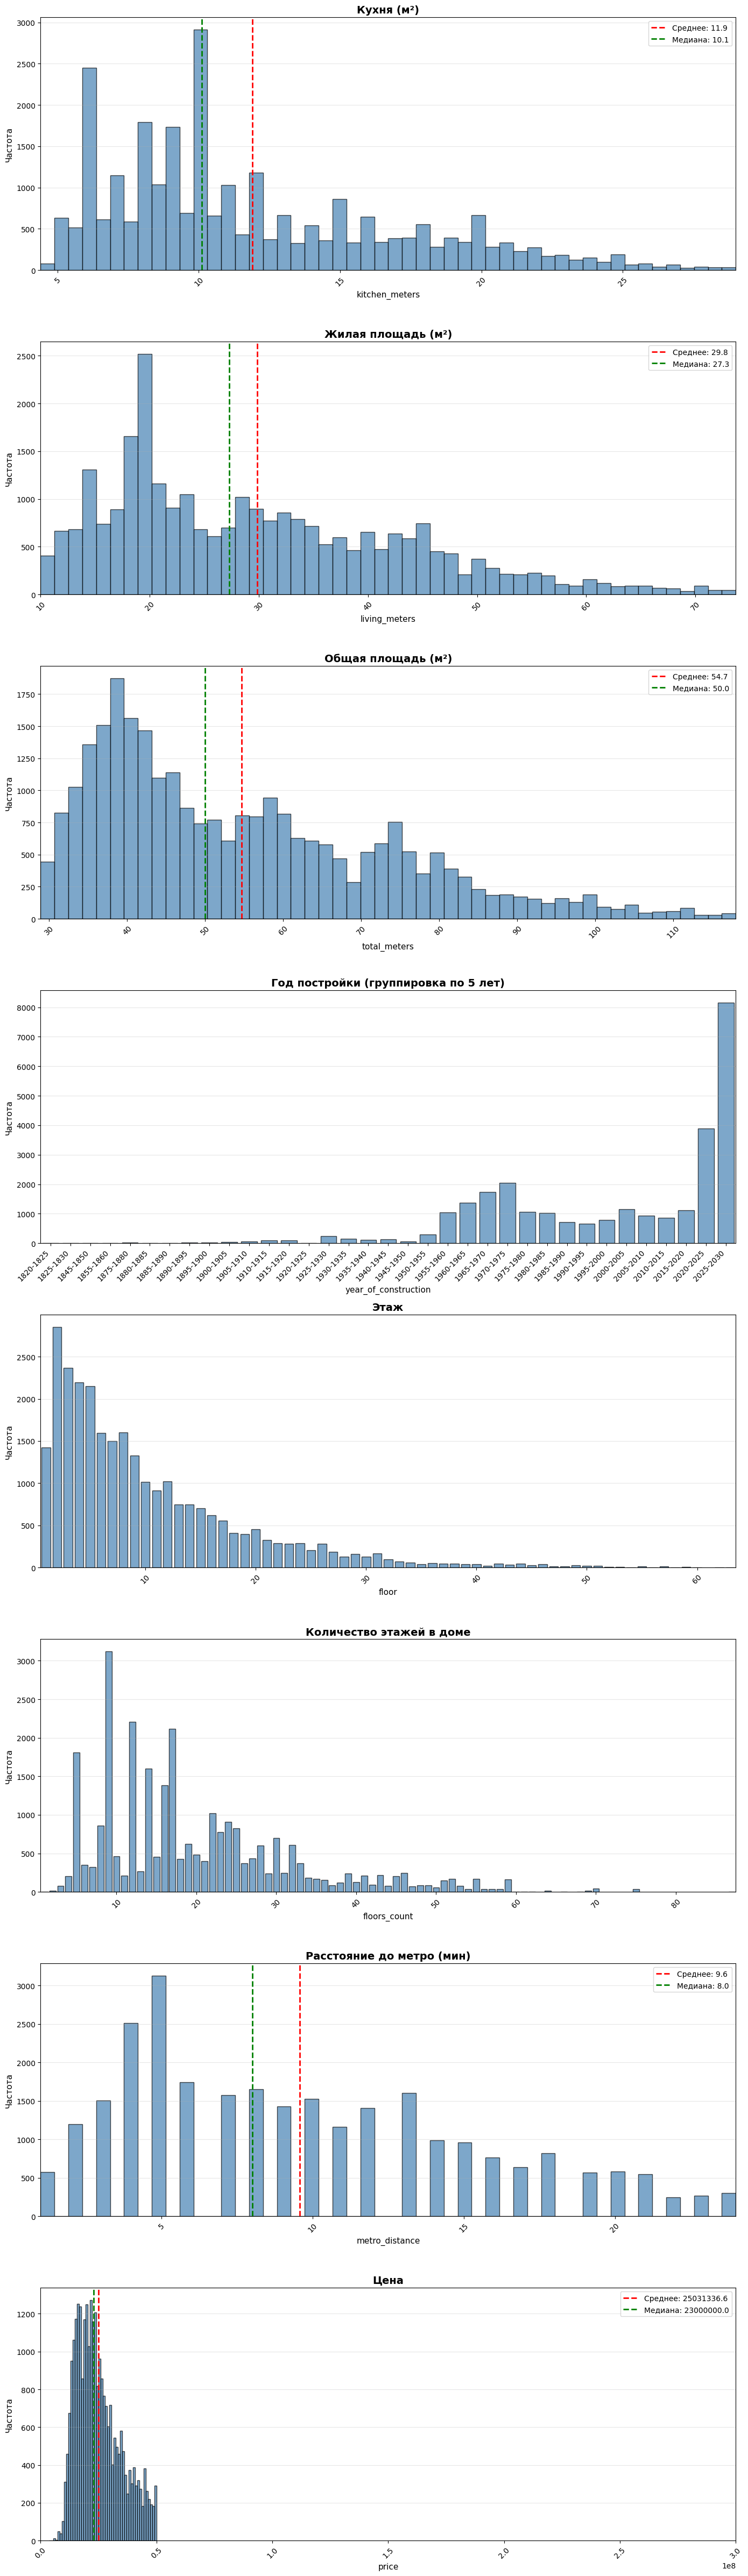


=== Статистика по числовым переменным ===

kitchen_meters:
  Среднее: 12.04
  Медиана: 10.10
  Стандартное отклонение: 5.67
  Min: 2.00, Max: 58.00
  Пропуски: 0

living_meters:
  Среднее: 30.17
  Медиана: 27.31
  Стандартное отклонение: 14.51
  Min: 1.20, Max: 120.00
  Пропуски: 0

total_meters:
  Среднее: 55.16
  Медиана: 50.00
  Стандартное отклонение: 20.41
  Min: 13.10, Max: 197.10
  Пропуски: 0

year_of_construction:
  Среднее: 1999.26
  Медиана: 2010.00
  Стандартное отклонение: 29.29
  Min: 1820.00, Max: 2030.00
  Пропуски: 0
  Распределение по группам (лет):
    1820-1825: 4 объектов
    1825-1830: 5 объектов
    1845-1850: 6 объектов
    1855-1860: 3 объектов
    1875-1880: 24 объектов
    1880-1885: 6 объектов
    1885-1890: 4 объектов
    1890-1895: 13 объектов
    1895-1900: 13 объектов
    1900-1905: 36 объектов
    1905-1910: 56 объектов
    1910-1915: 86 объектов
    1915-1920: 98 объектов
    1920-1925: 10 объектов
    1925-1930: 241 объектов
    1930-1935: 144 объект

In [249]:
visual(df)


# НЕ МЕНЯЯ РАЙОНЫ НА ОКРУГА

Регрессия

In [250]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
copy_df = df.copy()
df = copy_df.copy()
y = df['price']
df.drop(columns=['price'], inplace=True)
X = df
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)



regressor = LinearRegression()
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)


score_r2 = r2_score(y_test, y_pred)
rmse_score = root_mean_squared_error(y_test, y_pred)
mae_score = mean_absolute_error(y_test, y_pred)

print(f"score_r2 = {score_r2}")
print(f"rmse score = {rmse_score}")
print(f"mae score = {mae_score}")

score_r2 = 0.7518144215547987
rmse score = 4876239.916624778
mae score = 3667452.9849247644


Дерево

In [251]:
from sklearn.tree import DecisionTreeRegressor

df = copy_df.copy()
y = df['price']
df.drop(columns=['price'], inplace=True)
X = df
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


regressor = DecisionTreeRegressor()
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)


score_r2 = r2_score(y_test, y_pred)
rmse_score = root_mean_squared_error(y_test, y_pred)
mae_score = mean_absolute_error(y_test, y_pred)

print(f"score_r2 = {score_r2}")
print(f"rmse score = {rmse_score}")
print(f"mae score = {mae_score}")

score_r2 = 0.7942283690867796
rmse score = 4440067.210159502
mae score = 2052991.3755140726


KNN

In [252]:
from sklearn.neighbors import KNeighborsRegressor
df = copy_df.copy()
y = df['price']
df.drop(columns=['price'], inplace=True)
X = df
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


regressor = KNeighborsRegressor()
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)


score_r2 = r2_score(y_test, y_pred)
rmse_score = root_mean_squared_error(y_test, y_pred)
mae_score = mean_absolute_error(y_test, y_pred)

print(f"score_r2 = {score_r2}")
print(f"rmse score = {rmse_score}")
print(f"mae score = {mae_score}")

score_r2 = 0.7130170064474397
rmse score = 5243543.497526893
mae score = 3457784.2419337514
